# Debugging a Pricing Graph in Schenberg

> *"A whole pricing run is one lazy Polars query you execute once, at the edge."*

That design is what makes Schenberg fast and composable — but a single fused
`with_columns` is also **opaque** when something goes wrong: you collect, you get
a `null` NPV, and the expression tree gives you nowhere to put a breakpoint.

This notebook walks through the tools the engine gives you to make a lazy graph
**inspectable** instead, using a real CDI swap leg:

1. **Static introspection** — the graph documents itself (`explain`, `info`,
   `formula_of`, `required_inputs`). No data needed.
2. **Visualising the DAG** — turn the graph's own topology into a picture.
3. **`stage()` + null-propagation** — the core debugging move: materialise every
   intermediate so the *first* unexpectedly-null column is the root cause.
4. **What the picture reveals about simplifying the library** — a teaser for
   `REFACTORING_NOTES.md`.

Everything here is derived *from the graph itself*, so the diagnostics can never
drift from the formulas.

In [1]:
from pathlib import Path
HERE = Path(r'/home/user/risk-toolkit/notebooks')

In [2]:
from datetime import date
from typing import cast

%matplotlib inline
import matplotlib.pyplot as plt
import networkx as nx
import polars as pl
from pandera.typing.polars import LazyFrame

from schenberg.domain.schemas import SwapLegInput
from schenberg.market_data.snapshot import MarketSnapshot
from schenberg.market_data.sources import MarketSource
from schenberg.pricing.instruments.swap.legs.cdi import cdi_swap_leg_graph as leg_graph

pl.Config.set_tbl_rows(8)
print("graph under test:", leg_graph.name)

graph under test: cdi_swap_leg


## 1. The graph documents itself

Before touching any data, the graph can already tell you **what it needs**, **what
it reads from the market**, and **the exact order it evaluates formulas in** —
all read straight off the DAG, so it cannot lie about the code.

In [3]:
print(leg_graph.explain(view="pricing"))

Graph: cdi_swap_leg
Required inputs: accrual, id_indexador, notional, pay_receive, payment_days
Market outputs: forward_rate, zero_rate
Formula path:
  - cashflow_amount = \operatorname{cashflow_amount}(notional, forward_rate, accrual)
  - pay_receive_sign = \operatorname{pay_receive_sign}(pay_receive)
  - future_value = \operatorname{future_value}(cashflow_amount, pay_receive_sign)
  - T = \frac{d}{252}  # 252-day year fraction (time to maturity).
  - DF = e^{-rT}  # Continuously compounded discount factor off the zero curve.
  - PV = V \cdot DF  # Discount a future cashflow into local present value.


In [4]:
info = leg_graph.info(view="pricing")
print("required_inputs :", info.required_inputs)
print("market_inputs   :", info.market_inputs, " (the join keys)")
print("market_outputs  :", info.market_outputs, " (columns pulled from curves)")
print("formula_nodes   :", info.formula_nodes, " (topological order)")
print()
# A single formula's math label — `latex=...` metadata, never parsed, never executed:
print("discount_factor =", leg_graph.formula_of("discount_factor"))
print("year_fraction   =", leg_graph.formula_of("year_fraction"))

required_inputs : ('accrual', 'id_indexador', 'notional', 'pay_receive', 'payment_days')
market_inputs   : ('id_indexador', 'payment_days')  (the join keys)
market_outputs  : ('forward_rate', 'zero_rate')  (columns pulled from curves)
formula_nodes   : ('cashflow_amount', 'pay_receive_sign', 'future_value', 'year_fraction', 'discount_factor', 'present_value')  (topological order)

discount_factor = DF = e^{-rT}
year_fraction   = T = \frac{d}{252}


`required_inputs()` is the caller's contract: supply these columns or the join
keys, and the graph runs. Because it is computed from leaf `INPUT` nodes minus
what the market provides, **it can never drift from the formulas** — add a
formula that needs a new column and it shows up here automatically.

## 2. Picture the DAG

`to_mermaid()` emits a diagram for docs, but for a notebook we can render the
graph's own edge list with `networkx`. The colouring is taken entirely from the
graph's introspection API — **inputs**, **market reads**, **intermediate
formulas**, and **view outputs** — so the picture *is* the engine's view of the
computation.

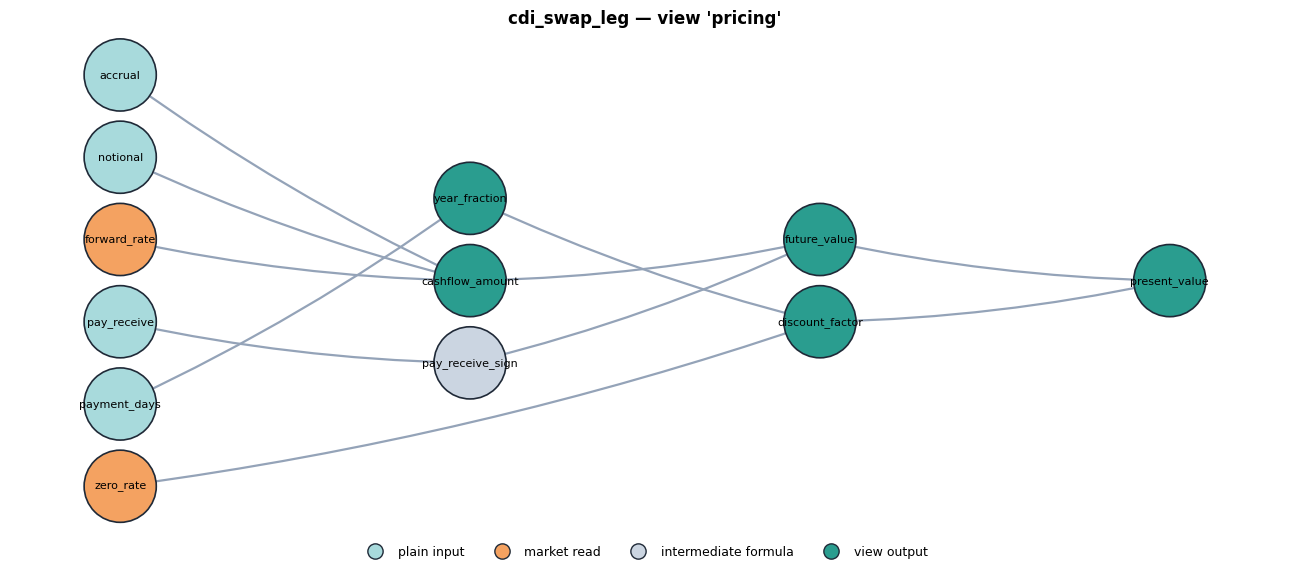

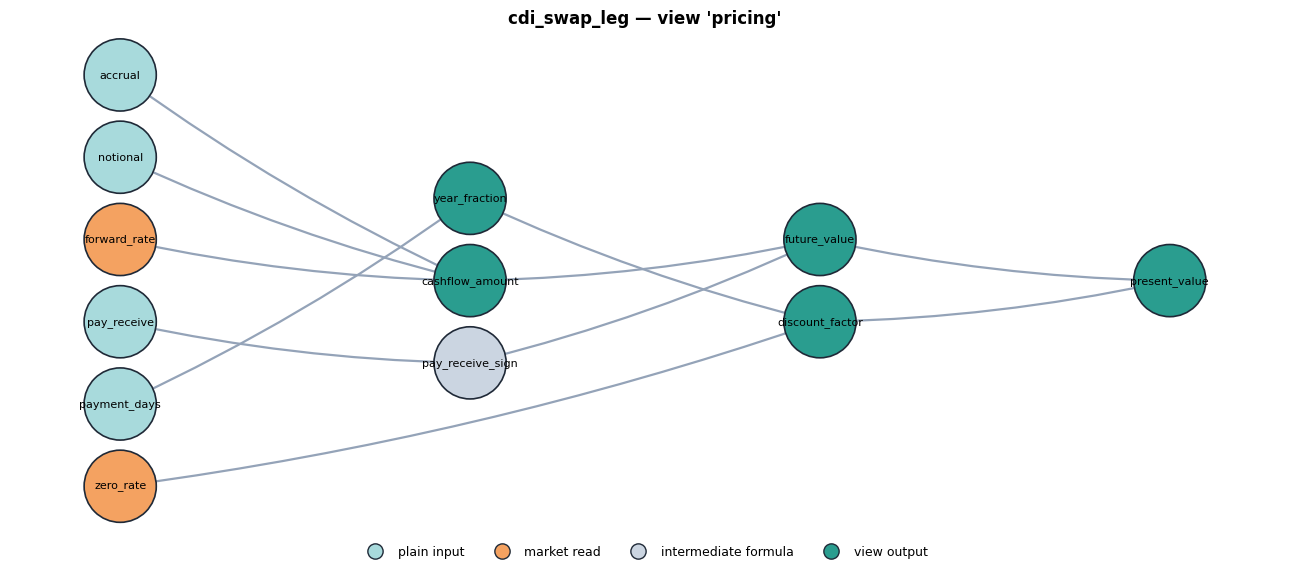

In [5]:
def graph_layout(graph, view="pricing"):
    info = graph.info(view=view)
    G = nx.DiGraph()
    G.add_edges_from(graph.edges())
    for layer, layer_nodes in enumerate(nx.topological_generations(G)):
        for n in layer_nodes:
            G.nodes[n]["layer"] = layer
    pos = nx.multipartite_layout(G, subset_key="layer", align="vertical")
    return G, pos, info


def classify(graph, info):
    market_out = set(info.market_outputs)
    formula_nodes = set(info.formula_nodes)
    view_nodes = set(info.view_nodes.values())

    def colour(n):
        if n in market_out:
            return "#f4a261"          # market read (curve column)
        if n not in formula_nodes:
            return "#a8dadc"          # plain input column
        if n in view_nodes:
            return "#2a9d8f"          # published view output
        return "#cbd5e1"              # internal intermediate

    return colour, formula_nodes


def render_graph(graph, view="pricing", title=None, ax=None, highlight=None,
                 save=None):
    G, pos, info = graph_layout(graph, view)
    colour, formula_nodes = classify(graph, info)
    highlight = set(highlight or ())

    node_colours, edge_colours, labels = [], [], {}
    for n in G.nodes():
        node_colours.append("#e63946" if n in highlight else colour(n))
        labels[n] = n  # plain node names keep the picture legible; math is in explain()
    for u, v in G.edges():
        edge_colours.append("#e63946" if u in highlight and v in highlight else "#94a3b8")

    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(13, 5.5))
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colours, arrows=True,
                           arrowsize=14, width=1.6, connectionstyle="arc3,rad=0.05")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colours, node_size=2700,
                           edgecolors="#1f2937", linewidths=1.2)
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8)
    ax.set_axis_off()
    ax.set_title(title or f"{graph.name} — view '{view}'", fontsize=12, fontweight="bold")
    if own_ax:
        fig.tight_layout()
        if save:
            fig.savefig(save, dpi=130, bbox_inches="tight")
        return fig


LEGEND = [
    ("plain input", "#a8dadc"),
    ("market read", "#f4a261"),
    ("intermediate formula", "#cbd5e1"),
    ("view output", "#2a9d8f"),
]


def legend_handles():
    return [plt.Line2D([0], [0], marker="o", linestyle="", markersize=11,
                       markerfacecolor=c, markeredgecolor="#1f2937", label=name)
            for name, c in LEGEND]


fig = render_graph(leg_graph, save=str(HERE / "images" / "01_cdi_leg_dag.png"))
fig.gca().legend(handles=legend_handles(), loc="lower center", ncol=4,
                 frameon=False, bbox_to_anchor=(0.5, -0.08), fontsize=9)
fig.savefig(HERE / "images" / "01_cdi_leg_dag.png", dpi=130, bbox_inches="tight")
fig

Read it left-to-right (dependency → dependent). The CDI leg pulls `zero_rate` and
`forward_rate` off the curve, builds a `cashflow_amount`, signs it by pay/receive,
discounts it, and lands on `pv`. **Every orange node is a market join that can
silently miss.** That is exactly where bugs come from — and where `stage()` earns
its keep.

## 3. The bug: an opaque `null` NPV

We price the same leg against two markets:

- a **healthy** curve keyed on `id_indexador = 1` (the leg's indexer), and
- a **broken** curve that only has `id_indexador = 99`, so the join misses.

In production this "broken" case is a mundane, common failure: a curve that
didn't load for one indexer, a key-type mismatch, a tenor that isn't on the grid.

In [6]:
def curve_market(indexer: int) -> MarketSnapshot:
    return MarketSnapshot.from_sources(
        as_of=date(2026, 6, 3),
        sources=[MarketSource("curves", pl.DataFrame({
            "id_indexador": [indexer], "tenor_days": [252],
            "zero_rate": [0.10], "forward_rate": [0.12],
        }).lazy())],
    )

good = curve_market(1)    # matches the leg
broken = curve_market(99) # join will miss -> null curve columns

leg = cast(LazyFrame[SwapLegInput], pl.DataFrame([{
    "swap_id": "SWP-1", "leg_id": "ativo", "leg_kind": "CDI",
    "pay_receive": "RECEIVE", "notional": 1_000_000.0, "id_indexador": 1,
    "payment_days": 252, "accrual": 1.0, "base_date": date(2026, 6, 3),
    "fixed_rate": None, "real_coupon": None, "cashflow_amount": None,
}]).lazy())

def priced_pv(market):
    out = cast(pl.DataFrame, leg_graph.compute(leg, market=market, view="pricing").collect())
    return out["pv"][0]

print(f"healthy pv : {priced_pv(good):,.2f}")
print(f"broken  pv : {priced_pv(broken)}")  # <- null; the fused query says nothing about why

healthy pv : 108,580.49
broken  pv : None


`compute()` fuses the whole graph into one expression, so a single missing curve
point gives you a bare `null` at the output with no trail. You cannot put a
breakpoint inside a Polars expression tree.

## 4. `stage()` to the rescue — null-propagation debugging

`stage()` runs the **same** graph but materialises *every intermediate node as its
own column*, in topological order. Nulls propagate downstream, so the **first**
column that turns null is the root cause — everything after it is just collateral.

In [7]:
staged = cast(pl.DataFrame, leg_graph.stage(leg, market=broken, view="pricing").collect())
# stage() materialises one column per *node*; the leg shares the discounted-cashflow
# backbone, so its signed cashflow is `future_value` and its pv is `present_value`.
ordered = ["forward_rate", "zero_rate", "cashflow_amount", "year_fraction",
           "discount_factor", "future_value", "present_value"]
staged.select(ordered)

forward_rate,zero_rate,cashflow_amount,year_fraction,discount_factor,future_value,present_value
f64,f64,f64,f64,f64,f64,f64
null,null,null,1.0,null,null,null


In [8]:
# null_count() across the staged frame, in evaluation order, pinpoints the culprit.
null_counts = staged.null_count()
bad_cols = [c for c in null_counts.columns if null_counts[c][0] > 0]

topo = [n for n in leg_graph.topological_order() if n in staged.columns]
first_null = next(n for n in topo if n in bad_cols)

print("columns that went null :", bad_cols)
print("first null in topo order:", first_null, "  <-- ROOT CAUSE")
print()
print("year_fraction survived  :", staged['year_fraction'][0],
      "(it only needs payment_days, which never touched the curve)")

columns that went null : ['fixed_rate', 'real_coupon', 'cashflow_amount', 'zero_rate', 'forward_rate', 'discount_factor', 'future_value', 'present_value']
first null in topo order: forward_rate   <-- ROOT CAUSE

year_fraction survived  : 1.0 (it only needs payment_days, which never touched the curve)


The diagnosis writes itself: **`forward_rate` / `zero_rate` are null because the
curve join missed**, and that nulls out `discount_factor → present_value`.
Meanwhile `year_fraction` is fine — it only depends on `payment_days`, which never
went near the curve. That contrast (one branch healthy, one branch dead) is the
fingerprint of a market-data join failure rather than a formula bug.

Let's paint the propagation back onto the DAG — the failed cone in red.

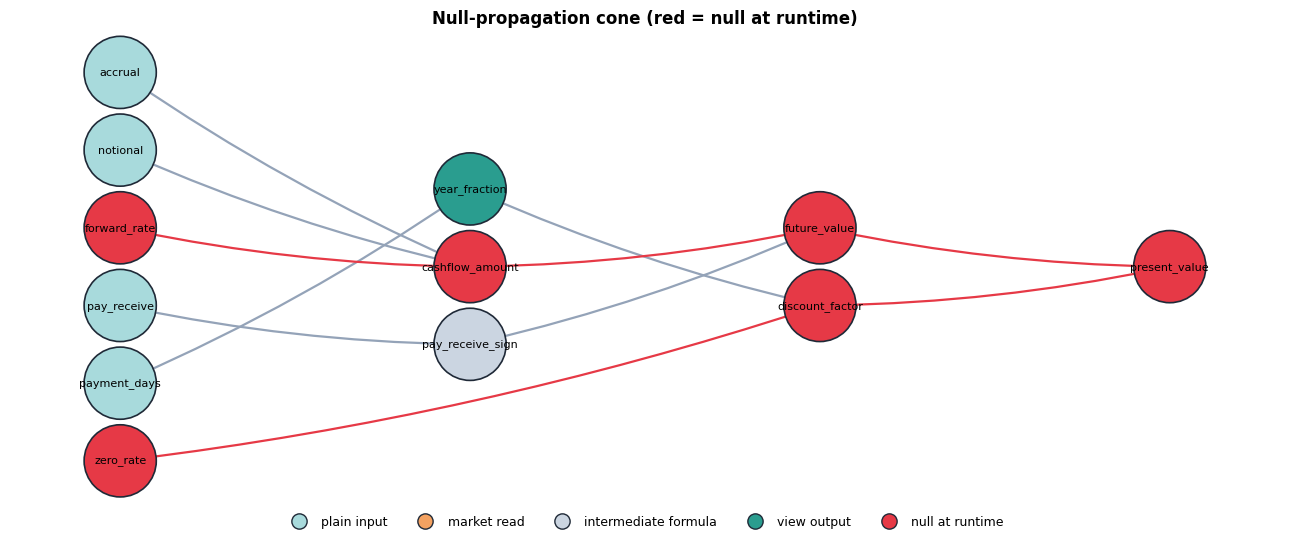

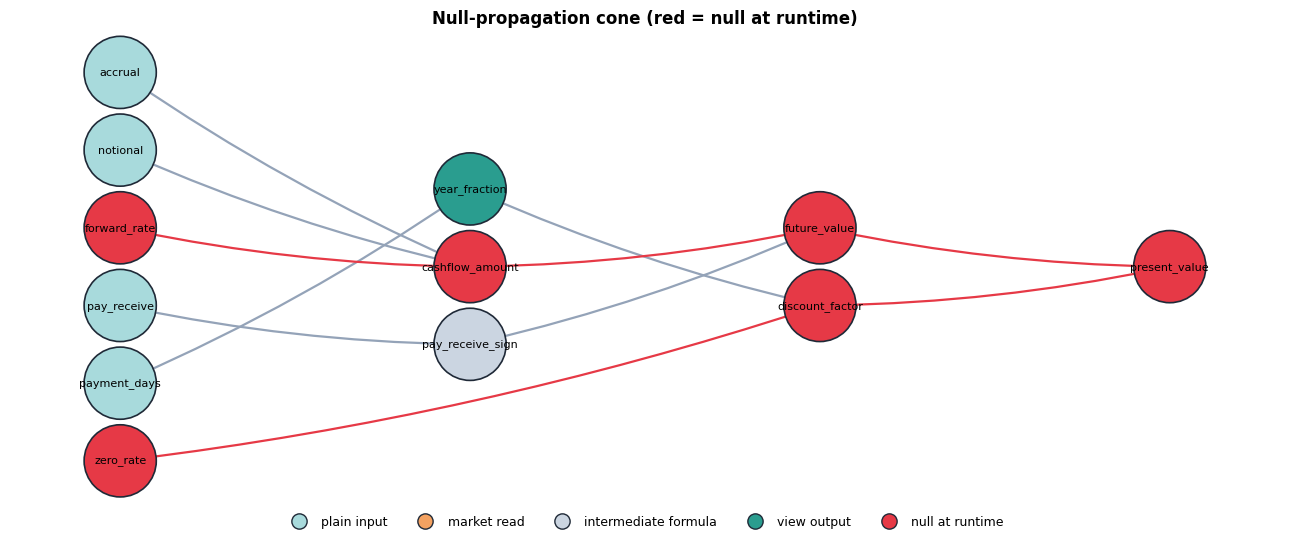

In [9]:
# The failure cone = the root-cause market columns + everything downstream of them.
failed = set(bad_cols)
for col in list(bad_cols):
    if col in leg_graph.topological_order():
        failed |= {d for d in leg_graph.topological_order()
                   if col in leg_graph.dependencies_of(d)}

fig, ax = plt.subplots(figsize=(13, 5.5))
render_graph(leg_graph, ax=ax, highlight=failed,
             title="Null-propagation cone (red = null at runtime)")
ax.legend(handles=legend_handles() +
          [plt.Line2D([0], [0], marker="o", linestyle="", markersize=11,
                      markerfacecolor="#e63946", markeredgecolor="#1f2937",
                      label="null at runtime")],
          loc="lower center", ncol=5, frameon=False,
          bbox_to_anchor=(0.5, -0.08), fontsize=9)
fig.tight_layout()
fig.savefig(HERE / "images" / "02_null_propagation.png", dpi=130, bbox_inches="tight")
fig

### The debugging checklist

| Tool | Question it answers | Needs data? |
|------|---------------------|-------------|
| `graph.explain(view=...)` | What does this graph compute, and in what order? | no |
| `graph.required_inputs()` | What must I supply for it to run? | no |
| `graph.info(view=...)` | What are the inputs / market reads / outputs? | no |
| `graph.to_mermaid(...)` | Show me the DAG (for docs / PRs). | no |
| `graph.stage(...).collect().null_count()` | **Which step actually broke?** | yes |
| `graph.dependencies_of(node)` | What feeds this node / what does it poison? | no |

The golden path for *"my NPV is null"*: **`stage` → `null_count` → first null in
`topological_order` → that node's market read or input is the bug.**

## 5. The picture drove a refactor — now implemented

Render the **generic forward** next to the **swap leg**: both are *the same
machine* — the shared `discounted_cashflow_graph` (`year_fraction →
discount_factor → present_value`) plus a per-instrument payoff that defines
`future_value`. This used to be duplicated; it is now **one shared backbone**.

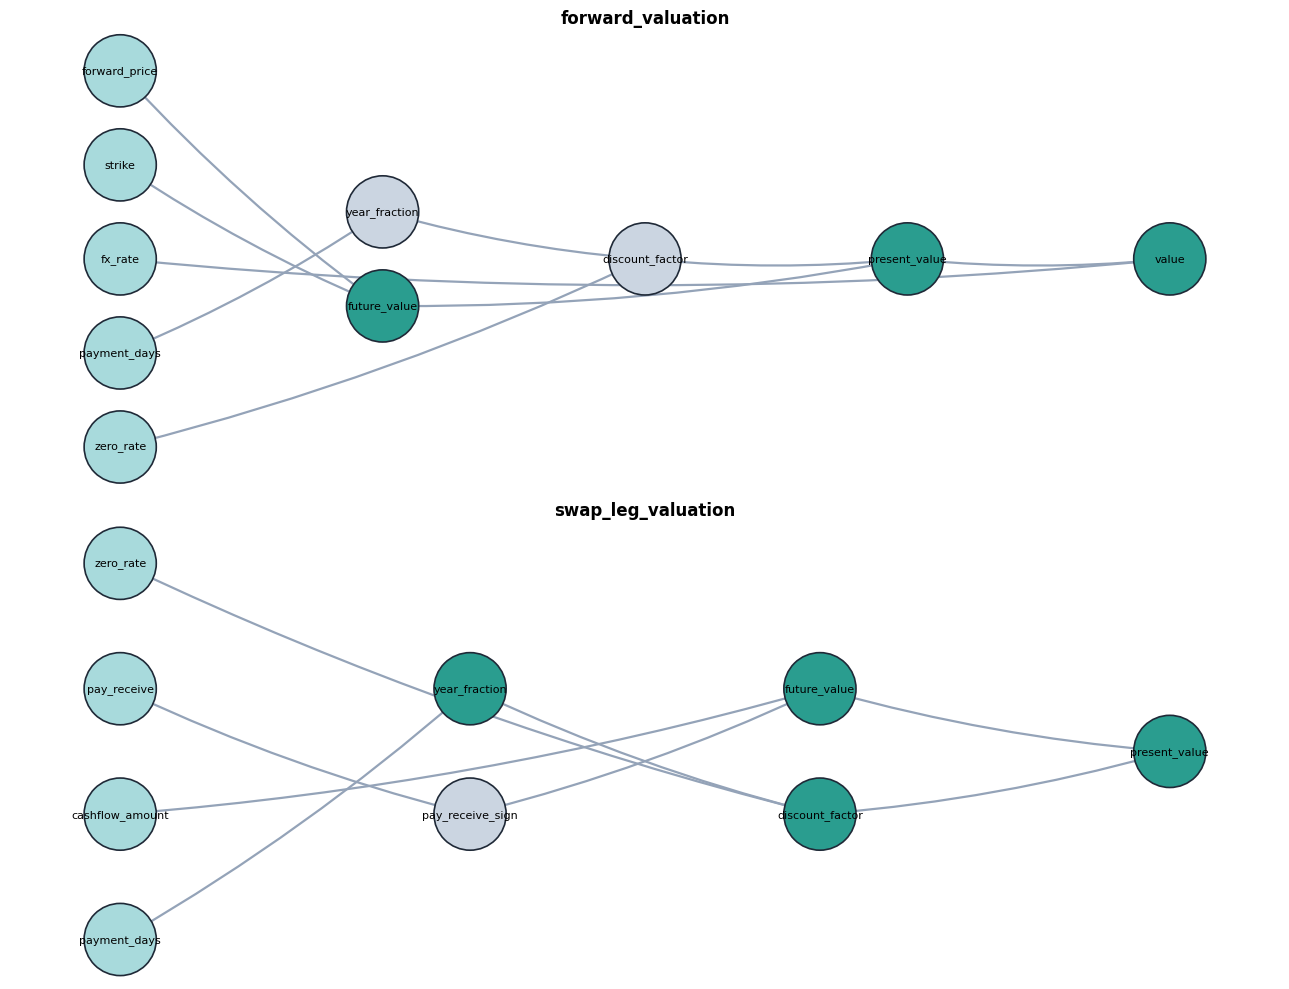

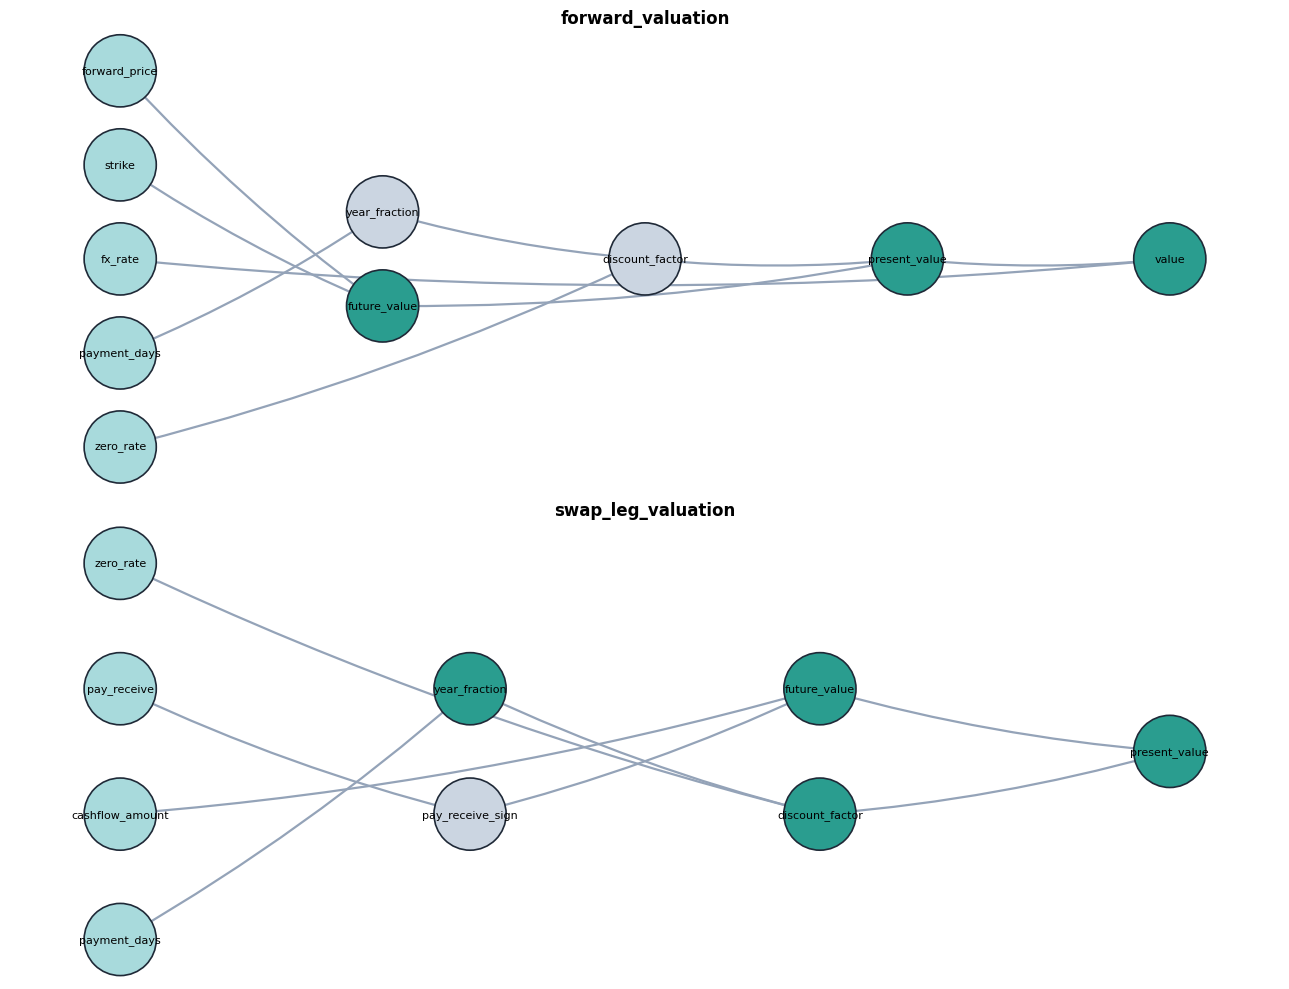

In [10]:
from schenberg.pricing.instruments.forward.generic import forward_valuation_graph
from schenberg.pricing.instruments.swap.generic import swap_leg_valuation_graph

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
render_graph(forward_valuation_graph, ax=axes[0], title="forward_valuation")
render_graph(swap_leg_valuation_graph, ax=axes[1], title="swap_leg_valuation")
fig.tight_layout()
fig.savefig(HERE / "images" / "03_forward_vs_swap.png", dpi=130, bbox_inches="tight")
fig

Both graphs now share the same `future_value → present_value` core (the right
half is identical). A forward's `future_value = forward_price - strike` and a swap
leg's `future_value = cashflow_amount × sign` are both just **"a future cashflow"**
fed into the one shared discount step; the only real difference is the payoff node
and whether an FX leg follows. The pay/receive sign is the leg's signed
**quantity** — the same role `side` plays for a structured-product leg.

What changed (all three landed in the library, tests and every number unchanged):

1. **One discounted-cashflow backbone.** `discounted_cashflow_graph` owns the
   `present_value = future_value × discount_factor` step; forward and swap leg
   compose it instead of each re-stating the discount-and-multiply.
2. **`compose` carries views + a single `assemble` verb.** The repeated
   `compose → for_market → returns` boilerplate is gone; every instrument graph is
   built through `FormulaGraph.assemble`.
3. **A simpler market layer.** One `JoinSpec` builds every keyed read; the
   `MarketRead` deferred-output class and its overloads are deleted, and
   `for_market` just names each column by its keyword.

The before/after rationale is in **[`REFACTORING_NOTES.md`](./REFACTORING_NOTES.md)**.